# 📊 Data Visualization for Genomic Insights

### Week 13 — Computational Biology Bootcamp

This notebook demonstrates core **data-visualization techniques** for genomics using **Matplotlib** and **Seaborn**, applied to a real **TCGA Invasive Breast Carcinoma** cohort (692 patients).

For **every** plot you will find a short note that answers three questions:
- **Why this plot?** — what question it is built to answer
- **When to use it** — the kind of data/variable it suits
- **What to read from it** — the biological/analytical meaning to extract

> 💡 *Visualization in genomics is not decoration — it is how we surface mutation patterns, detect outliers (e.g. hypermutators), and generate hypotheses before formal statistics.*

---

## 1. Setup & Loading the Data

Run the cell below. On **Google Colab** it opens an upload dialog so you can select `Assignment Dataset.csv`. If the file already sits next to the notebook (e.g. running locally), it loads directly without prompting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Reproducibility for any sampling/jitter
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Global aesthetic — applied once so every plot inherits a clean, publication-friendly style
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110

FILENAME = "Assignment Dataset.csv"

def load_dataset(filename=FILENAME):
    """Load the dataset whether we are on Colab (upload) or local (file present)."""
    if os.path.exists(filename):
        return pd.read_csv(filename)
    try:
        from google.colab import files  # available only inside Colab
        print(f"'{filename}' not found locally — please upload it.")
        uploaded = files.upload()
        # Use whatever file the user actually uploaded
        return pd.read_csv(next(iter(uploaded)))
    except ModuleNotFoundError:
        raise FileNotFoundError(
            f"'{filename}' not found and not running on Colab. "
            "Place the CSV next to this notebook."
        )

df = load_dataset()
print("Loaded shape:", df.shape)
df.head()

'Assignment Dataset.csv' not found locally — please upload it.


Saving Assignment Dataset.csv to Assignment Dataset.csv
Loaded shape: (692, 11)


,Patient ID,Mutation Count,Overall Survival Status,Cancer Type,Sex,total_segments,mean_seg_mean,gain_segments,loss_segments,frac_gain,frac_loss
0,TCGA-AR-A0TX,247,0:LIVING,Invasive Breast Carcinoma,Female,320,0.463892,187,60,0.584375,0.187500
1,TCGA-AR-A0TY,55,1:DECEASED,Invasive Breast Carcinoma,Female,461,0.165284,197,130,0.427332,0.281996
2,TCGA-AR-A0TZ,47,1:DECEASED,Invasive Breast Carcinoma,Female,288,-0.092613,158,99,0.548611,0.343750
3,TCGA-AR-A0U0,29,0:LIVING,Invasive Breast Carcinoma,Female,205,-0.099761,58,61,0.282927,0.297561
4,TCGA-AR-A0U1,73,0:LIVING,Invasive Breast Carcinoma,Female,397,-0.026987,119,111,0.299748,0.279597


## 2. Inspect the Data Before Plotting

**Always look at the raw structure first.** Choosing the wrong plot for a variable is the most common visualization mistake — and it starts with not knowing your columns' types and ranges.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692 entries, 0 to 691
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               692 non-null    object 
 1   Mutation Count           692 non-null    int64  
 2   Overall Survival Status  692 non-null    object 
 3   Cancer Type              692 non-null    object 
 4   Sex                      692 non-null    object 
 5   total_segments           692 non-null    int64  
 6   mean_seg_mean            692 non-null    float64
 7   gain_segments            692 non-null    int64  
 8   loss_segments            692 non-null    int64  
 9   frac_gain                692 non-null    float64
 10  frac_loss                692 non-null    float64
dtypes: float64(3), int64(4), object(4)
memory usage: 59.6+ KB


In [3]:
print("\n--- Numeric summary ---")
display(df.describe().T)

print("\n--- Categorical columns ---")
for col in ["Overall Survival Status", "Cancer Type", "Sex"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


--- Numeric summary ---


,count,mean,std,min,25%,50%,75%,max
Mutation Count,692.0,52.579480,95.846345,0.000000,18.000000,29.000000,51.000000,1142.000000
total_segments,692.0,336.573699,565.616751,35.000000,121.000000,233.000000,400.250000,8088.000000
mean_seg_mean,692.0,-0.042880,0.222837,-2.290769,-0.167904,-0.041851,0.078391,1.308098
gain_segments,692.0,110.476879,160.979575,0.000000,20.000000,66.000000,143.000000,1786.000000
loss_segments,692.0,92.505780,260.156702,2.000000,28.000000,56.000000,99.000000,3935.000000
frac_gain,692.0,0.280389,0.148688,0.000000,0.156110,0.284574,0.399291,0.689956
frac_loss,692.0,0.252845,0.083853,0.053467,0.195253,0.250654,0.309047,0.569799



--- Categorical columns ---

Overall Survival Status:
Overall Survival Status
0:LIVING      578
1:DECEASED    114
Name: count, dtype: int64

Cancer Type:
Cancer Type
Invasive Breast Carcinoma    692
Name: count, dtype: int64

Sex:
Sex
Female    685
Male        7
Name: count, dtype: int64


> ### ⚠️ Data-literacy note: not every column is plottable
>
> Inspection reveals two columns that are **poor grouping variables** for this cohort — a critical thing to notice *before* you waste a figure on them:
>
> - **`Cancer Type`** has a **single value** (`Invasive Breast Carcinoma`) for all 692 patients. A variable with no variation carries no information — a bar/count plot of it would be one meaningless bar.
> - **`Sex`** is **685 Female vs 7 Male**. Comparing groups of size 685 and 7 is statistically unreliable; any 'difference' you'd see is driven by tiny-sample noise.
>
> 👉 The robust grouping variable in this dataset is **`Overall Survival Status`** (578 LIVING / 114 DECEASED), so that is what we compare against throughout.

Let's create a couple of tidy helper columns to make plots more readable.

In [4]:
# Clean, human-readable survival label (drops the '0:' / '1:' prefix)
df["Survival"] = df["Overall Survival Status"].str.split(":").str[1].str.title()

# Pseudocount column for log-scaled plots.
# 66 patients have a Mutation Count of exactly 0, and log(0) is undefined (-inf).
# Adding 1 before logging ("+1 pseudocount") is the standard genomics fix: it keeps
# every patient in the plot instead of silently dropping the zeros.
df["Mutation Count +1"] = df["Mutation Count"] + 1

# Numeric genomic metrics we will reuse repeatedly
numeric_cols = [
    "Mutation Count", "total_segments", "mean_seg_mean",
    "gain_segments", "loss_segments", "frac_gain", "frac_loss",
]

# Fixed colors for survival so the meaning is consistent across every figure
survival_palette = {"Living": "#4C72B0", "Deceased": "#C44E52"}

print(f'{(df["Mutation Count"] == 0).sum()} patients have 0 mutations -> handled by the +1 pseudocount')
df[["Survival"] + numeric_cols].head()

66 patients have 0 mutations -> handled by the +1 pseudocount


,Survival,Mutation Count,total_segments,mean_seg_mean,gain_segments,loss_segments,frac_gain,frac_loss
0,Living,247,320,0.463892,187,60,0.584375,0.187500
1,Deceased,55,461,0.165284,197,130,0.427332,0.281996
2,Deceased,47,288,-0.092613,158,99,0.548611,0.343750
3,Living,29,205,-0.099761,58,61,0.282927,0.297561
4,Living,73,397,-0.026987,119,111,0.299748,0.279597


---
## 3. Count Plot — Cohort Composition

**Why this plot?** A **count plot** (categorical bar of frequencies) answers *“how many patients fall in each category?”* It is the right first plot for any categorical variable.

**When to use it:** Discrete/categorical data where you care about group sizes.

**What to read from it:** Here it exposes **class imbalance** — far more LIVING than DECEASED patients. This matters because every later comparison between the two groups must be read with that imbalance in mind (the smaller group is noisier).

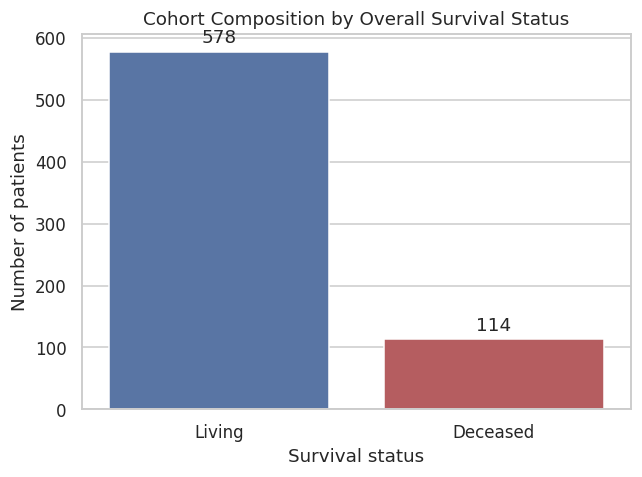

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.countplot(data=df, x="Survival", hue="Survival",
              palette=survival_palette, legend=False, ax=ax)

# sns.countplot(df, x='Survival', hue='Survival', palette='viridis')

# Annotate each bar with its exact count
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

ax.set_title("Cohort Composition by Overall Survival Status")
ax.set_xlabel("Survival status")
ax.set_ylabel("Number of patients")
plt.tight_layout()
plt.show()

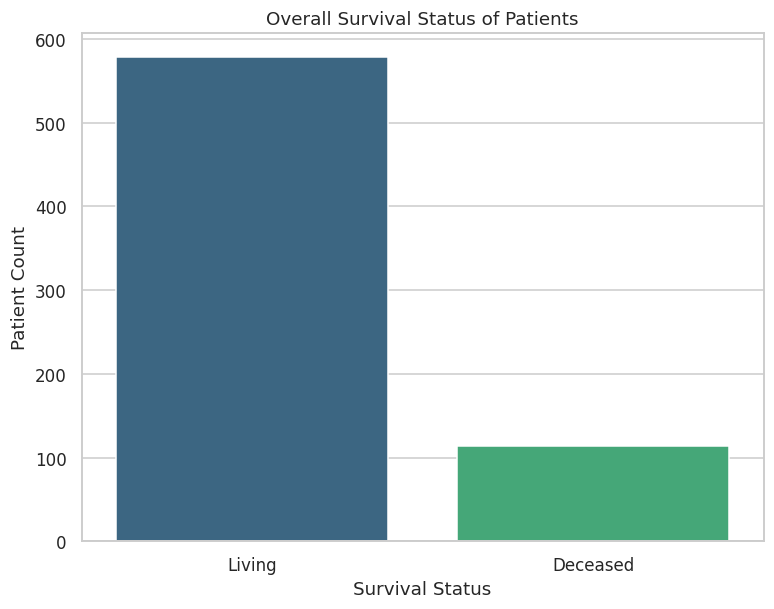

In [10]:
# basic format
plt.figure(figsize=(8, 6))
sns.countplot(df, x='Survival', hue="Survival", palette='viridis')
plt.xlabel("Survival Status")
plt.ylabel("Patient Count")
plt.title("Overall Survival Status of Patients")
plt.show()

---
## 4. Histogram + KDE — Distribution of Mutation Count

**Why this plot?** A **histogram** shows the *shape* of a single continuous variable — where values cluster, how spread out they are, and whether there are outliers. The overlaid **KDE** (smooth density curve) makes the shape easier to see.

**When to use it:** One continuous variable, when you want its full distribution rather than just a mean.

**What to read from it:** Mutation Count is strongly **right-skewed** — most tumours carry relatively few mutations, but a long tail of **hypermutator** tumours reaches into the hundreds/thousands. A single 'average mutation count' would be misleading here; the *shape* is the insight.

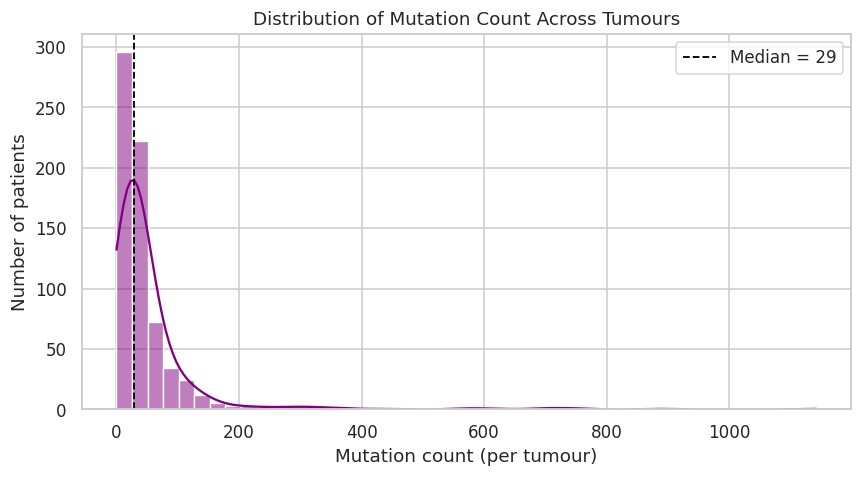

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=df, x="Mutation Count", bins=45, kde=True,
             color="purple", ax=ax)

median_mut = df["Mutation Count"].median()
ax.axvline(median_mut, color="black", linestyle="--", linewidth=1.2,
           label=f"Median = {median_mut:.0f}")

ax.set_title("Distribution of Mutation Count Across Tumours")
ax.set_xlabel("Mutation count (per tumour)")
ax.set_ylabel("Number of patients")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Log-Scaled Histogram — Taming Skew

**Why this plot?** When data spans several orders of magnitude (as mutation counts do), a linear axis crushes most of the data against the left edge. Plotting on a **log scale** spreads the values out so structure becomes visible. This is a routine, essential technique in genomics (mutation burden, expression, read counts).

**When to use it:** Heavily right-skewed, strictly-positive continuous variables.

**What to read from it:** On the log axis the distribution looks far more **symmetric / bell-shaped** \u2014 evidence the underlying process is roughly *log-normal*. This justifies log-transforming mutation count before correlation or modelling, and makes the typical range readable instead of hidden in a spike.

> 🔑 **Handling zeros:** 66 tumours have **0** mutations, and `log(0)` is undefined. We plot **`Mutation Count + 1`** (a *pseudocount*) so those patients are kept rather than silently dropped \u2014 a small detail that prevents a misleading figure.

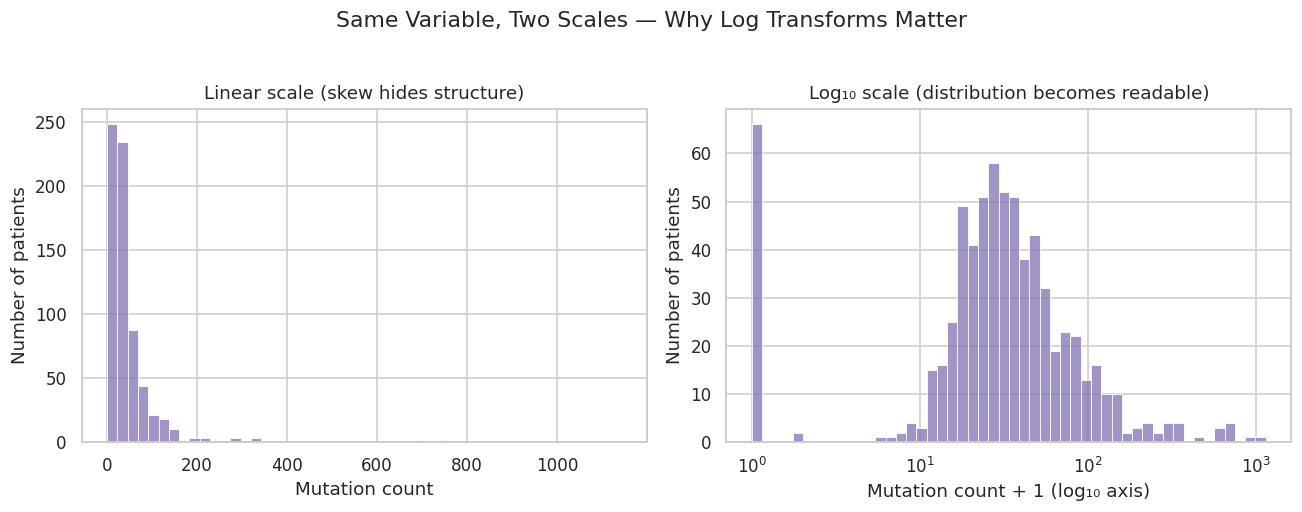

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: original linear scale (for contrast)
sns.histplot(data=df, x="Mutation Count", bins=50, color="#8172B3", ax=axes[0])
axes[0].set_title("Linear scale (skew hides structure)")
axes[0].set_xlabel("Mutation count")
axes[0].set_ylabel("Number of patients")

# Right: log10 x-axis on the +1 pseudocount (keeps the 66 zero-mutation tumours)
sns.histplot(data=df, x="Mutation Count +1", bins=50, color="#8172B3",
             log_scale=True, ax=axes[1])
axes[1].set_title("Log\u2081\u2080 scale (distribution becomes readable)")
axes[1].set_xlabel("Mutation count + 1 (log\u2081\u2080 axis)")
axes[1].set_ylabel("Number of patients")

fig.suptitle("Same Variable, Two Scales \u2014 Why Log Transforms Matter", y=1.03)
plt.tight_layout()
plt.show()



---
## 6. Box Plot + Violin Plot — Mutation Burden by Survival

**Why this plot?** To compare a **continuous variable across categories**, a **box plot** summarises each group's median, quartiles, and outliers, while a **violin plot** adds the full density shape. Side by side they let you compare both the *typical value* and the *spread* between groups.

**When to use it:** One continuous variable split by a categorical group (here: mutation count by survival status).

**What to read from it:** Look at whether the **medians and spreads differ** between LIVING and DECEASED. Overlapping boxes suggest mutation count alone does not cleanly separate outcomes; the long upper whiskers/outliers flag the hypermutators again. *(We use a log y-axis because of the skew shown above.)*

In [17]:
df.head()

,Patient ID,Mutation Count,Overall Survival Status,Cancer Type,Sex,total_segments,mean_seg_mean,gain_segments,loss_segments,frac_gain,frac_loss,Survival,Mutation Count +1
0,TCGA-AR-A0TX,247,0:LIVING,Invasive Breast Carcinoma,Female,320,0.463892,187,60,0.584375,0.187500,Living,248
1,TCGA-AR-A0TY,55,1:DECEASED,Invasive Breast Carcinoma,Female,461,0.165284,197,130,0.427332,0.281996,Deceased,56
2,TCGA-AR-A0TZ,47,1:DECEASED,Invasive Breast Carcinoma,Female,288,-0.092613,158,99,0.548611,0.343750,Deceased,48
3,TCGA-AR-A0U0,29,0:LIVING,Invasive Breast Carcinoma,Female,205,-0.099761,58,61,0.282927,0.297561,Living,30
4,TCGA-AR-A0U1,73,0:LIVING,Invasive Breast Carcinoma,Female,397,-0.026987,119,111,0.299748,0.279597,Living,74


In [ ]:
df["log_mutation"] = np.log1p(df["Mutation Count"])

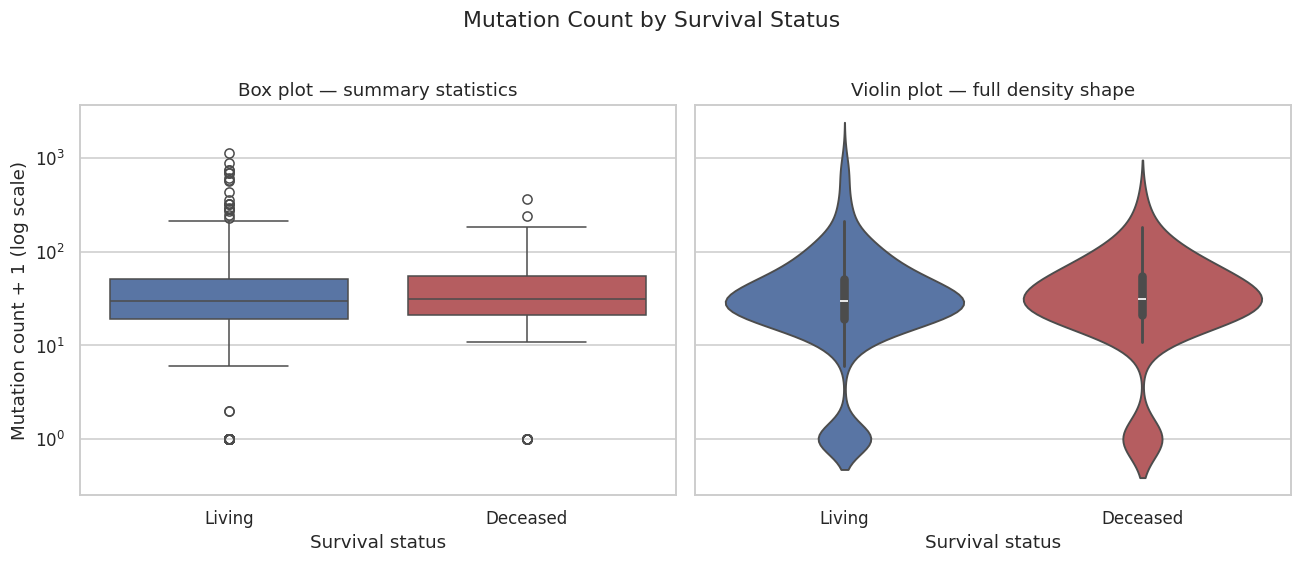

In [18]:
order = ["Living", "Deceased"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot the +1 pseudocount on a log scale. log_scale=True lets seaborn build the
# box/KDE in log space directly; using the raw column (which contains zeros) would
# make log(0) = -inf and crash the violin's density estimate.
sns.boxplot(data=df, x="Survival", y="Mutation Count +1", order=order,
            hue="Survival", palette=survival_palette, legend=False,
            log_scale=True, ax=axes[0])
axes[0].set_title("Box plot \u2014 summary statistics")
axes[0].set_xlabel("Survival status")
axes[0].set_ylabel("Mutation count + 1 (log scale)")

sns.violinplot(data=df, x="Survival", y="Mutation Count +1", order=order,
               hue="Survival", palette=survival_palette, legend=False,
               log_scale=True, ax=axes[1])
axes[1].set_title("Violin plot \u2014 full density shape")
axes[1].set_xlabel("Survival status")
axes[1].set_ylabel("")

fig.suptitle("Mutation Count by Survival Status", y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Scatter Plot — Relationship Between Two Genomic Metrics

**Why this plot?** A **scatter plot** is the canonical way to show the **relationship between two continuous variables** — whether they rise together, trade off, or are unrelated. Adding a **hue** encodes a third (categorical) variable.

**When to use it:** Two continuous variables; optionally a third categorical via color.

**What to read from it:** We plot the fraction of the genome **gained** vs **lost** (copy-number instability), colored by survival. Read the **direction and tightness** of the cloud: do tumours that gain a lot also lose a lot (overall genomic instability), or is there a trade-off? Check whether DECEASED points sit preferentially in the high-instability region.

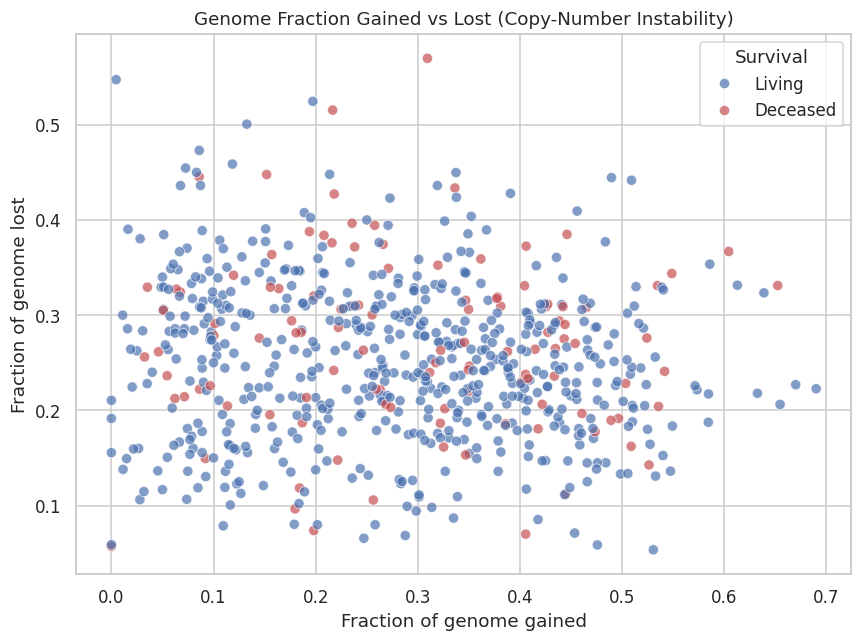

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="frac_gain", y="frac_loss", hue="Survival",
                palette=survival_palette, alpha=0.7, s=45,
                hue_order=order, ax=ax)

ax.set_title("Genome Fraction Gained vs Lost (Copy-Number Instability)")
ax.set_xlabel("Fraction of genome gained")
ax.set_ylabel("Fraction of genome lost")
ax.legend(title="Survival")
plt.tight_layout()
plt.show()

---
## 8. Correlation Heatmap — Which Metrics Move Together

**Why this plot?** A **heatmap** of a correlation matrix encodes the pairwise relationships among *all* numeric variables at once, using color intensity. It is the fastest way to spot **redundant** and **independent** features.

**When to use it:** Many numeric variables, when you want a whole-picture overview of how they co-vary (feature selection, redundancy checks).

**What to read from it:** Strong positive cells (e.g. `total_segments` with `gain_segments`/`loss_segments`) reveal metrics that are essentially **measuring the same thing** — you would not feed all of them into a model. Weak/near-zero cells flag **independent** signals worth keeping. The `frac_gain` vs `frac_loss` cell tells you whether gains and losses are coupled.

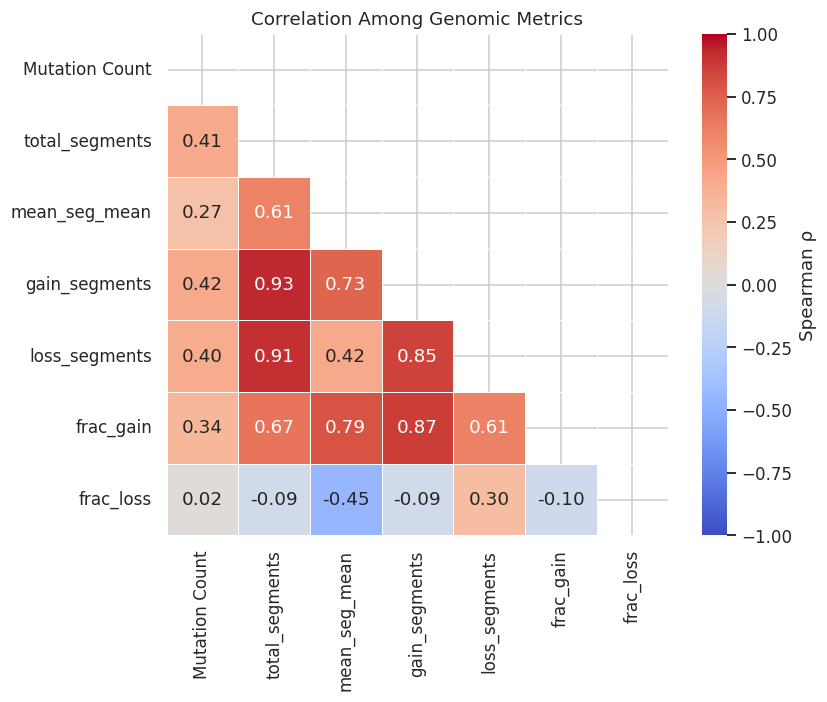

In [20]:
corr = df[numeric_cols].corr(method="spearman")  # Spearman: robust to the skew/outliers

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide the redundant upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, cbar_kws={"label": "Spearman \u03c1"}, ax=ax)

ax.set_title("Correlation Among Genomic Metrics")
plt.tight_layout()
plt.show()

---
## 9. Pair Plot — Multi-Variable Overview at a Glance

**Why this plot?** A **pair plot** draws every pairwise scatter *and* each variable's distribution on the diagonal, in one grid. It is an excellent **exploratory** first pass for a handful of variables before committing to specific plots.

**When to use it:** A small set (≈3–6) of continuous variables you want to explore jointly; hue by a category to look for separation.

**What to read from it:** Scan the off-diagonal panels for **linear trends or clusters**, and the diagonals for **per-group distribution shifts**. If the DECEASED density sits shifted on any diagonal, that variable is a candidate signal worth a focused follow-up plot.

> *We restrict to a few interpretable metrics — a pair plot of too many variables becomes unreadable.*

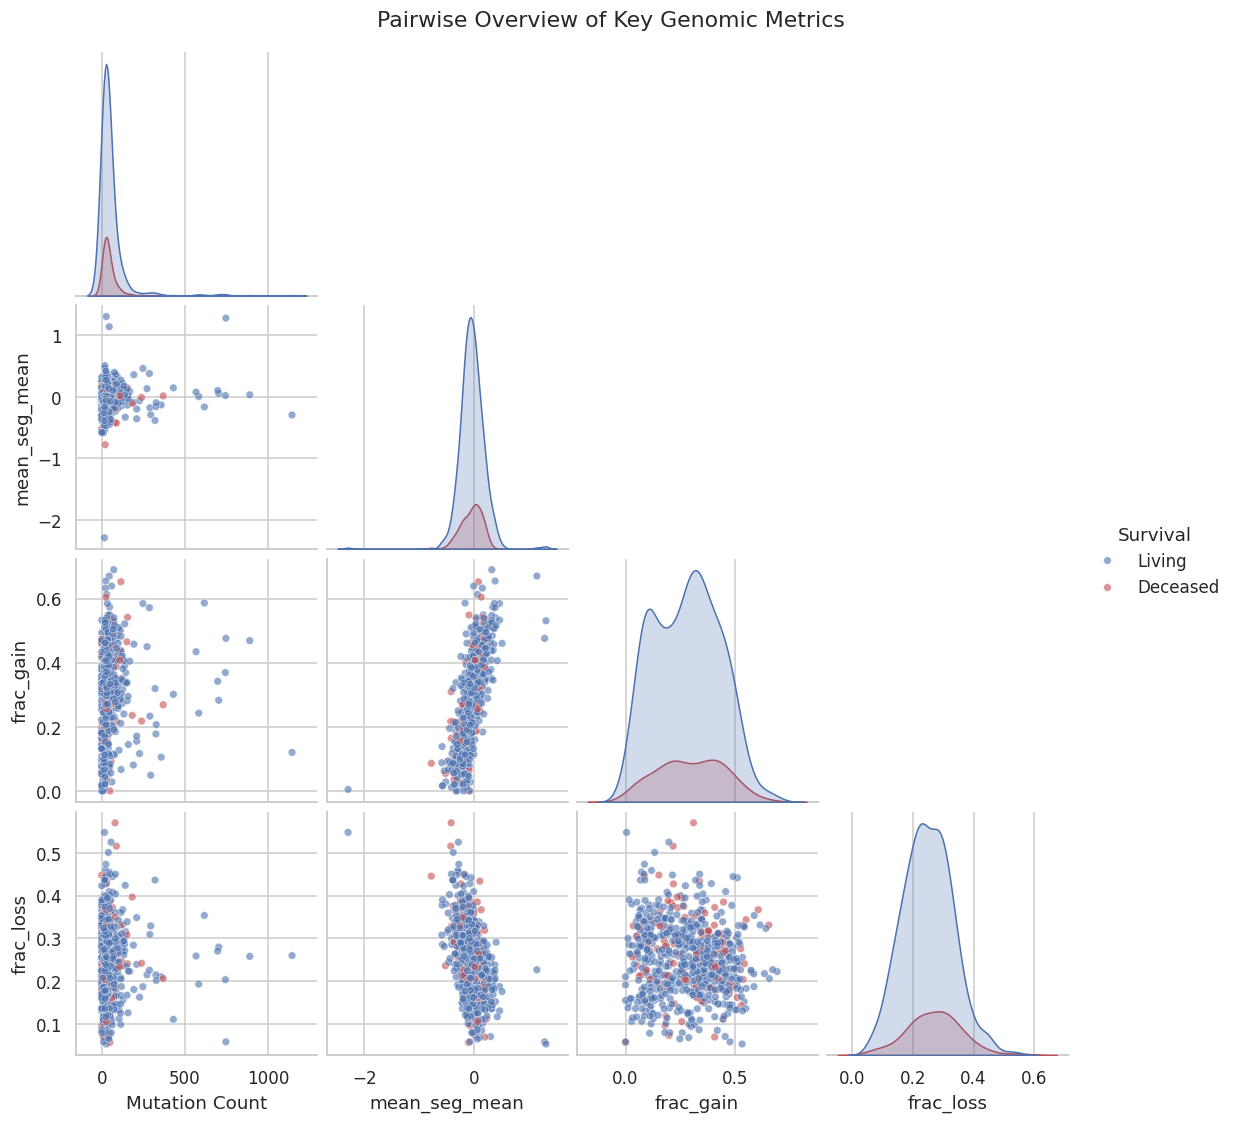

In [23]:
pair_cols = ["Mutation Count", "mean_seg_mean", "frac_gain", "frac_loss"]

g = sns.pairplot(df, vars=pair_cols, hue="Survival", hue_order=order,
                 palette=survival_palette, corner=True,
                 plot_kws={"alpha": 0.6, "s": 25},
                 diag_kind="kde")
g.figure.suptitle("Pairwise Overview of Key Genomic Metrics", y=1.02)
plt.show()

---
## 10. Clustermap — Discovering Patient Subgroups

**Why this plot?** A **clustermap** combines a heatmap with **hierarchical clustering**: it reorders rows (patients) and columns (metrics) so that similar profiles sit together, and draws dendrograms showing the grouping. This is how you *discover* structure you didn't specify in advance.

**When to use it:** A samples × features matrix when you want to find natural subgroups or co-varying features. Values must be **standardized** (z-scored) first so that variables on different scales contribute fairly.

**What to read from it:** Look for **blocks** of similar color — these are clusters of patients with a shared genomic profile (e.g. a high-instability subgroup). The column dendrogram re-confirms which metrics behave alike. The row color strip lets you check whether any cluster is enriched for DECEASED patients — a hypothesis for a prognostic subgroup.

> *We standardize each metric to z-scores and sample patients for legibility; the seed makes it reproducible.*

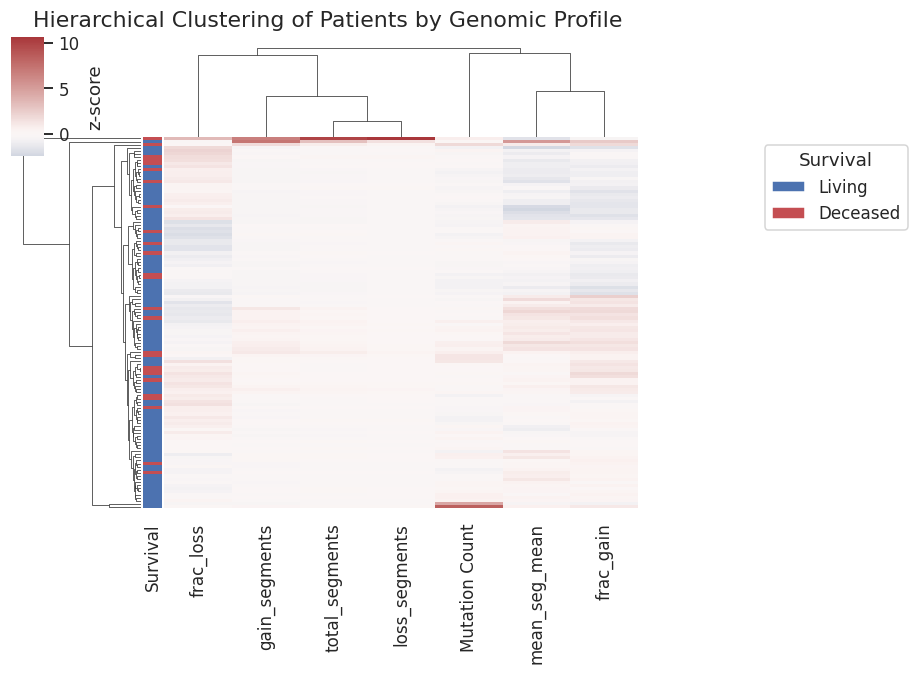

In [25]:
# Sample patients so the row dendrogram stays readable (full 692 rows is cluttered)
sample = df.sample(n=120, random_state=RANDOM_SEED).copy()

# z-score each metric: (x - mean) / std  -> puts all metrics on a comparable scale
matrix = sample[numeric_cols]
matrix_z = (matrix - matrix.mean()) / matrix.std()

# Color strip on the rows showing each patient's survival status
row_colors = sample["Survival"].map(survival_palette)

g = sns.clustermap(matrix_z, cmap="vlag", center=0,
                   row_colors=row_colors, figsize=(6, 6),
                   xticklabels=True, yticklabels=False,
                   cbar_kws={"label": "z-score"})
g.figure.suptitle("Hierarchical Clustering of Patients by Genomic Profile", y=1.02)

# Manual legend for the survival row-color strip
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=l) for l, c in survival_palette.items()]
g.ax_heatmap.legend(handles=handles, title="Survival",
                    bbox_to_anchor=(1.25, 1.0), loc="upper left")
plt.show()

---
## 11. Summary — From Pixels to Biology

| Plot | Question it answers | Genomic takeaway |
|------|--------------------|------------------|
| Count plot | How many per group? | Cohort is **imbalanced** (living ≫ deceased) — read all comparisons accordingly |
| Histogram + KDE | What is the shape of one variable? | Mutation count is **right-skewed** with a **hypermutator** tail |
| Log histogram | Is the variable log-normal? | Log scale reveals near-symmetric structure — justifies log-transform |
| Box / violin | Does a variable differ across groups? | Compare mutation burden between survival groups (medians + spread) |
| Scatter | How do two variables relate? | Genome gain vs loss → **copy-number instability** pattern |
| Correlation heatmap | Which metrics are redundant? | Segment-count metrics co-vary; flags features to drop |
| Pair plot | Quick joint overview? | Screens several metrics at once for trends/separation |
| Clustermap | Are there hidden subgroups? | Hierarchical clusters = candidate **prognostic subtypes** |

### Key principles demonstrated
1. **Inspect before you plot** — and reject uninformative variables (constant `Cancer Type`, imbalanced `Sex`).
2. **Match the plot to the variable type** — categorical → count plot; one continuous → histogram; two continuous → scatter; many → heatmap/clustermap.
3. **Respect the data's distribution** — skewed genomic counts need **log scales** and **rank-based (Spearman)** correlation.
4. **Every figure should answer a question** and carry labels, units, and a title so a collaborator can read it unaided.

*Happy plotting! — Week 13, Computational Biology Bootcamp* 🧬